# Loop Engineering: From Static Prompts to Self-Improving AI Workflows

**Based on:** [Loop Engineering by Addy Osmani](https://addyosmani.com/blog/loop-engineering/)

---

## What Is Loop Engineering?

> *"Loop engineering is replacing yourself as the person who prompts the agent. Instead, you design the system that does the prompting for you.."*

<img src="figures/Traditional vs Loop engineering.png" width="800">

Traditional AI usage: **you → prompt → model → output**

Loop engineering: **you design a system → the system prompts the model → the model iterates toward a goal**

This shifts your role from *prompt writer* to *system designer*.

---

## What We Will Build

We will test the following hypothesis using a local Qwen model:

> **Hypothesis:** *A loop with a maker agent + checker agent produces higher-quality outputs than a single-pass generation, even with a small local model.*

<img src="figures/Lab Workflow.png" width="800">
We will build this in three stages:

1. **Baseline** : single-pass generation (no loop)
3. **Iterative loop using Maker + Checker Loop** : two specialized sub-agents split the work

All inference runs locally via **llama.cpp server + Qwen 3.5 9B**.

## Connect to Language Model

You can run this tutorial in one of two ways:

1. **Local model via SSH**
   Use this option if you have access to a GPU machine or remote workstation.

2. **OpenAI API**
   Use this option if you do not have access to a GPU.

Both options use the `openai` Python SDK, so the rest of the notebook can follow the same logic.
<img src="figures/Step 1.png" width="800">

---

## Option A — Local Model via SSH

In this setup, the model runs on a remote machine using `llama-server`.

> **Note**
> You will learn the full details of local model deployment, `llama-server`, and GGUF models in **Lab 05** of the **Applied Small Models AI Lab**.

This option uses:

* `llama-server`
* a local GGUF model, for example `Qwen3.5-9B-UD-Q4_K_XL.gguf`
* the `openai` Python SDK
* SSH port forwarding

Open your SSH connection with port forwarding:


Run `start_server.sh` in a terminal which I included in the code directory. Please note that you might adapt it to your operating system


```text
http://localhost:8888
```

---

## Option B — OpenAI API

Use this option if you do not have access to a GPU or prefer to run the tutorial with a cloud-hosted model.

Install the OpenAI SDK:

```bash
pip install openai
```

Set your OpenAI API key:

```bash
export OPENAI_API_KEY="sk-your-api-key"
```

I provide the code below, you need to include you API key. .


In [1]:
!pip install openai --quiet

## Option A-1: Run your Local sLM

In [2]:
import urllib.request
import json
import sys

SERVER_PORT = 8080
HEALTH_URL  = f"http://localhost:{SERVER_PORT}/health"

try:
    with urllib.request.urlopen(HEALTH_URL, timeout=5) as resp:
        data   = json.loads(resp.read())
        status = data.get("status", data)
        if str(status).lower() == "ok":
            print(f"Server is running and ready at localhost:{SERVER_PORT}")
        else:
            print(f"Server responded but status = {status!r}")
except Exception as e:
    print(f"Cannot reach server: {e}")
    print()
    print("Make sure you ran start_server.sh from your terminal first.")
    print("Command:")
    print("  bash /home/lenovo/Desktop/applied-slm-lab/Labs/special_lessons/Loop_engineering/start_server.sh")
    sys.exit(1)

Server is running and ready at localhost:8080


---
## Option A-2: Using Local Model

We wrap the OpenAI SDK to always point at our local server.  
The API is identical — we just change the `base_url`.

In [3]:
# using local model
import re
from openai import OpenAI

LOCAL_MODEL = "qwen3.5-9b"

client = OpenAI(
    base_url=f"http://localhost:{SERVER_PORT}/v1",
    api_key="not-needed", # your local server does not require authentication
)


---
## Option B — Using OpenAI API

We wrap the OpenAI SDK to always point at our local server.  
we need `API-key`.

In [ ]:
import os
from openai import OpenAI as OpenAIClient

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")  # or paste key: "sk-..."
OPENAI_MODEL   = "gpt-4o"

client = OpenAIClient(api_key=OPENAI_API_KEY)


---
## Step 2 — Create Chat Function to communicate with Local or cloud hosted Language Model
<img src="figures/Step 2.png" width="800">

> **Note**
> Deatiled explanation about Chat template and parameters used in this section is provided in **Lab 1 and Lab 2** of the **Applied Small Models AI Lab**.



In [4]:
def chat(messages: list[dict], temperature: float = 0.7, max_tokens: int = 1024) -> str:
    """
    Call the local Qwen model and return the final answer only.

    The server runs with --reasoning-format deepseek, which routes Qwen3's
    chain-of-thought into message.reasoning_content and keeps message.content
    as the clean answer. No regex stripping needed.

    The regex below is kept as a fallback in case any stray tags slip through.
    """
    response = client.chat.completions.create(
        model=LOCAL_MODEL,
        messages=messages,
        temperature=temperature,
        max_tokens=max_tokens,
    ) # if you are using 
    msg  = response.choices[0].message
    # Primary: content field (clean answer, no thinking tags with deepseek format)
    text = msg.content or ""
    # Fallback: strip any residual <think> blocks
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL).strip()
    return text

# Smoke test — should print a plain sentence with no <think> tags
result = chat([{"role": "user", "content": "Say hello in one sentence."}])
print(result)

Hello! How can I assist you today?


---
## Baseline: Single-Pass Generation (No Loop)

This is the traditional approach: one prompt → one output.  
We will use this as our **control** to compare against the loop later.

**Task:** Write a concise explanation of *gradient descent* for a beginner.

In [5]:
TASK = "Write a concise explanation of gradient descent for a complete beginner. Use an analogy."

baseline_output = chat([
    {"role": "system", "content": "You are a helpful teacher. Be clear and concise."},
    {"role": "user",   "content": TASK},
])

print("=== BASELINE OUTPUT (single pass) ===")
print(baseline_output)

=== BASELINE OUTPUT (single pass) ===
**Gradient Descent** is a method used to find the best possible answer (the lowest error) in a mathematical problem.

**The Analogy: Blindfolded Hiker**
Imagine you are a hiker standing on a foggy mountain slope with a blindfold on. Your goal is to reach the bottom of the valley as quickly as possible. You cannot see where the bottom is, but you can feel the ground under your feet.

1.  **Feel the Slope (The Gradient):** You stick out your hand and feel which direction the ground is steepest. This tells you the direction of the steepest *ascent*. To go down, you do the opposite.
2.  **Take a Step:** You take a step in the direction that goes down fastest.
3.  **Repeat:** You check your hand again, take another step, and repeat until you can no longer feel a downward slope. At that point, you have reached the bottom.

**In Simple Terms**
*   The **mountain** is your problem (e.g., a complex math equation).
*   The **bottom** is the best solution (th

---
## Step 4 — The Skill: Codified Knowledge
<img src="figures/Step 3.png" width="800">

In loop engineering, **Skills** are reusable instruction sets so agents don't re-derive context.  
We encode our quality criteria as a skill that will drive every iteration of the loop.

In [6]:
# Skills are just structured prompts stored as Python dicts (or files in a real system)
# This code creates two reusable agent instructions: one to judge writing quality, and one to improve the writing based on that judgment.

WRITING_SKILL = """
You are an expert technical writer. Your quality criteria for any explanation:

1. ANALOGY       — includes at least one real-world analogy
2. BREVITY       — under 150 words
3. JARGON-FREE   — no unexplained technical terms
4. ACTIONABLE    — ends with what the reader should do or understand next

Rate each criterion as PASS or FAIL. Be strict.
"""

REFINEMENT_SKILL = """
You are a rewriter. Given feedback on a piece of writing, improve it.
Keep the same core idea. Address every FAIL point in the feedback.
Do not add unnecessary length. Return ONLY the improved text.
"""

print("Skills defined.")

Skills defined.


---
## Step 4 — Sub-agents: The Maker and the Checker
<img src="figures/Step 4.png" width="800">

> *"The model that wrote the code is way too nice grading its own homework."*

We split responsibility across two agents:

| Agent | Role | Prompt Style |
|---|---|---|
| **Maker** | Drafts or refines the output | Creative, generative (high temerture for craetivity)|
| **Checker** | Evaluates against skill criteria | Critical, structured (low temperture) |

Both agents hit the same local Qwen model — but with different system prompts and temperatures.

In [7]:
def maker_agent(task: str, feedback: str = None) -> str:
    """
    Maker: generates or refines content.
    Uses a high temperature for creative variation and a large token budget
    because Qwen3's thinking preamble can be several hundred tokens.
    """
    if feedback is None:
        user_msg = task
    else:
        user_msg = (
            f"Original task: {task}\n\n"
            f"Feedback to address:\n{feedback}\n\n"
            "Rewrite to fix all FAIL points. Return ONLY the improved text."
        )
    return chat(
        [{"role": "system", "content": REFINEMENT_SKILL},
         {"role": "user",   "content": user_msg}],
        temperature=0.8,
        max_tokens=2048,
    )


def checker_agent(output: str) -> tuple[str, int]:
    """
    Checker: evaluates output against the four skill criteria.
    Uses a low temperature for consistent, structured judgements.
    Returns (feedback_text, pass_count).
    """
    user_msg = (
        f"Evaluate this text against all four criteria:\n\n---\n{output}\n---\n\n"
        "For each criterion write exactly one line in this format:\n"
        "[CRITERION NAME]: PASS or FAIL — reason (one sentence)\n\n"
        "Criteria to check: ANALOGY, BREVITY, JARGON-FREE, ACTIONABLE"
    )
    feedback = chat(
        [{"role": "system", "content": WRITING_SKILL},
         {"role": "user",   "content": user_msg}],
        temperature=0.1,
        max_tokens=2048,
    )
    score = feedback.upper().count("PASS")
    return feedback, score


print("Sub-agents defined.")

Sub-agents defined.


---
## Step 5 — Loop, State Management(logging), Select and Pick Best Prompt

<img src="figures/Step 5.png" width="800">



--- 
## Step 5-A

> *"The model forgets everything between runs so the memory has to be on disk."*

We persist loop state to a JSON file so every iteration starts with full context.  
In a production loop, this would be a database or a Linear board.

In [8]:
import json
from pathlib import Path
from datetime import datetime

STATE_FILE = Path("/tmp/loop_state.json")

def load_state() -> dict:
    if STATE_FILE.exists():
        return json.loads(STATE_FILE.read_text())
    return {"iterations": [], "best_output": None, "passed": False}

def save_state(state: dict):
    STATE_FILE.write_text(json.dumps(state, indent=2))

def log_iteration(state: dict, iteration: int, output: str, feedback: str, score: int):
    state["iterations"].append({
        "iteration":  iteration,
        "timestamp":  datetime.now().isoformat(),
        "output":     output,
        "feedback":   feedback,
        "score":      score,
    })
    if score > (state.get("best_score") or 0):
        state["best_output"] = output
        state["best_score"]  = score
    save_state(state)

# Reset state for a clean run
STATE_FILE.unlink(missing_ok=True)
print("State file reset.")

State file reset.


### Example: Saved Loop State

The loop state is stored as a JSON object. It keeps track of each iteration, the feedback received, the score, the best output so far, and whether the loop has passed.

```json
{
  "iterations": [
    {
      "iteration": 1,
      "timestamp": "2026-06-16T10:30:00",
      "output": "First draft...",
      "feedback": "Too long.",
      "score": 2
    }
  ],
  "best_output": "First draft...",
  "best_score": 2,
  "passed": false
}
```

In this example:

* `iterations` stores the history of all loop attempts.
* `output` is the text generated in that iteration.
* `feedback` is the evaluator's response.
* `score` shows how good the output was.
* `best_output` stores the best result so far.
* `passed` tells us whether the loop has successfully met the criteria.


---
## Step 5-B — The Loop

Now we wire everything together.  

The loop runs until one of two stopping conditions:
- **Goal met:** checker gives 4/4 PASS (all criteria satisfied)
- **Max iterations:** we cap at 5 to control token cost

This is the `/goal` primitive described in the blog — *"runs until a condition you wrote is actually true."*

In [9]:
MAX_ITERATIONS = 5
GOAL_SCORE     = 4   # all four criteria must PASS

state    = load_state()
feedback = None
current_output = None

print(f"Task: {TASK}")
print(f"Goal: {GOAL_SCORE}/4 criteria PASS\n")
print("=" * 60)

for i in range(1, MAX_ITERATIONS + 1):
    print(f"\n--- ITERATION {i} ---")

    # MAKER: draft or refine
    current_output = maker_agent(TASK, feedback)
    print(f"[MAKER OUTPUT]\n{current_output}\n")

    # CHECKER: evaluate
    feedback, score = checker_agent(current_output)
    print(f"[CHECKER FEEDBACK] (score: {score}/{GOAL_SCORE})\n{feedback}\n")

    # STATE: persist everything
    log_iteration(state, i, current_output, feedback, score)

    # GOAL CHECK
    if score >= GOAL_SCORE:
        state["passed"] = True
        save_state(state)
        print(f"Goal reached at iteration {i}!")
        break
    else:
        print(f"Not there yet. {GOAL_SCORE - score} criteria still failing. Looping...")

print("\n" + "=" * 60)
print(f"Loop finished. Goal met: {state['passed']}")

Task: Write a concise explanation of gradient descent for a complete beginner. Use an analogy.
Goal: 4/4 criteria PASS


--- ITERATION 1 ---
[MAKER OUTPUT]
Imagine you are blindfolded at the top of a foggy mountain and need to reach the lowest valley. Gradient descent works like this: you feel the ground beneath your feet to determine the steepest direction downward, take a small step that way, and repeat the process. With every step, you use the same logic to adjust your path until you can no longer go lower, guaranteeing you've found the bottom.

[CHECKER FEEDBACK] (score: 3/4)
ANALOGY: PASS — The text uses the clear real-world analogy of a blindfolded hiker descending a foggy mountain to explain the concept.
BREVITY: PASS — The explanation is concise and stays well under the 150-word limit.
JARGON-FREE: PASS — All terms are explained through context or avoided entirely without requiring prior technical knowledge.
ACTIONABLE: FAIL — The text describes a process but fails to tell the 

---
---
## Step 5-C — The Loop Compare Baseline vs. Loop Output

In [10]:
state = load_state()

print("=" * 60)
print("BASELINE (single pass)")
print("=" * 60)
print(baseline_output)

print()
print("=" * 60)
print(f"LOOP BEST OUTPUT (iteration {state['best_score']}/4 criteria)")
print("=" * 60)
print(state["best_output"])

print()
print("=" * 60)
print(f"Total iterations run: {len(state['iterations'])}")
print(f"Score progression:    {[it['score'] for it in state['iterations']]}")

BASELINE (single pass)
**Gradient Descent** is a method used to find the best possible answer (the lowest error) in a mathematical problem.

**The Analogy: Blindfolded Hiker**
Imagine you are a hiker standing on a foggy mountain slope with a blindfold on. Your goal is to reach the bottom of the valley as quickly as possible. You cannot see where the bottom is, but you can feel the ground under your feet.

1.  **Feel the Slope (The Gradient):** You stick out your hand and feel which direction the ground is steepest. This tells you the direction of the steepest *ascent*. To go down, you do the opposite.
2.  **Take a Step:** You take a step in the direction that goes down fastest.
3.  **Repeat:** You check your hand again, take another step, and repeat until you can no longer feel a downward slope. At that point, you have reached the bottom.

**In Simple Terms**
*   The **mountain** is your problem (e.g., a complex math equation).
*   The **bottom** is the best solution (the lowest error)

### LLM as a Judge: Baseline vs. Loop Best Output

| Aspect                | Baseline: Single Pass                              | Loop Best Output                                         | Insight                                                                         |
| --------------------- | -------------------------------------------------- | -------------------------------------------------------- | ------------------------------------------------------------------------------- |
| **Clarity**           | Very clear, but long and detailed.                 | Clear and compact.                                       | The loop output is easier to read quickly.                                      |
| **Analogy**           | Strong hiker/mountain analogy with multiple steps. | Also uses a hiker analogy, but in a shorter form.        | Both use analogy well, but the baseline is more vivid.                          |
| **Brevity**           | Too long for a short explanation.                  | Much shorter and more focused.                           | The loop output better satisfies the brevity criterion.                         |
| **Jargon-Free**       | Explains terms such as gradient and learning rate. | Mostly simple, but still introduces gradient directly.   | The baseline explains jargon better; the loop is simpler overall.               |
| **Actionable Ending** | Ends with a strong conceptual takeaway.            | Ends with concrete steps: calculate slope, move, repeat. | The loop output is more actionable.                                             |
| **Educational Depth** | Better as a beginner-friendly mini lesson.         | Better as a concise summary.                             | Baseline is better for teaching; loop output is better for quick understanding. |
| **Overall Quality**   | Informative, but over-explains.                    | More aligned with the four target criteria.              | The loop improved the answer by optimizing toward explicit quality goals.       |

### Key Insight

The baseline answer is useful and educational, but it is longer than necessary. The loop best output is more concise, more focused, and better aligned with the evaluation criteria: analogy, brevity, jargon-free language, and actionable guidance.

This shows the value of loop engineering: instead of accepting the first answer, the system evaluates the output, identifies weak points, and improves the answer over multiple iterations.


---
## Visualise Score Progression

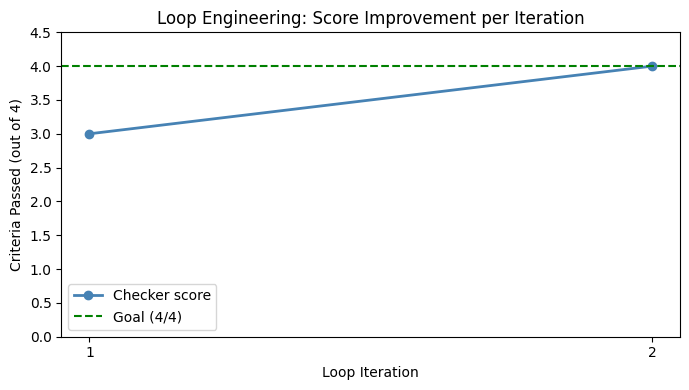

Plot saved to /tmp/loop_score.png


In [11]:
import matplotlib.pyplot as plt

state = load_state()
scores = [it["score"] for it in state["iterations"]]
iters  = list(range(1, len(scores) + 1))

plt.figure(figsize=(7, 4))
plt.plot(iters, scores, marker="o", linewidth=2, color="steelblue", label="Checker score")
plt.axhline(y=GOAL_SCORE, color="green", linestyle="--", label=f"Goal ({GOAL_SCORE}/4)")
plt.xlabel("Loop Iteration")
plt.ylabel("Criteria Passed (out of 4)")
plt.title("Loop Engineering: Score Improvement per Iteration")
plt.ylim(0, 4.5)
plt.xticks(iters)
plt.legend()
plt.tight_layout()
plt.savefig("/tmp/loop_score.png", dpi=120)
plt.show()
print("Plot saved to /tmp/loop_score.png")

---
## Inspect the Persistent State File

This demonstrates the **state management** component.  
Every iteration's output, feedback, and score is on disk — the loop can resume after a crash.

In [12]:
state = load_state()

print(f"State file: {STATE_FILE}")
print(f"Iterations logged: {len(state['iterations'])}")
print(f"Goal achieved: {state['passed']}")
print(f"Best score: {state.get('best_score')}/4")
print()

for it in state["iterations"]:
    print(f"Iteration {it['iteration']} | Score: {it['score']}/4 | {it['timestamp']}")

State file: /tmp/loop_state.json
Iterations logged: 2
Goal achieved: True
Best score: 4/4

Iteration 1 | Score: 3/4 | 2026-06-18T11:17:11.522053
Iteration 2 | Score: 4/4 | 2026-06-18T11:17:18.367438


---
## Clean Up the Server

In [ ]:
# To stop the server, run this in your terminal:
#   bash start_server.sh stop
#
# Or run the line below — it sends SIGTERM to any running llama-server process.
import subprocess
result = subprocess.run(["pkill", "-f", "llama-server"], capture_output=True)
print("Server stopped." if result.returncode == 0 else "No running server found.")

---
## Summary

| Concept | What We Did |
|---|---|
| **Automation** | Python `for` loop as the trigger; state file as the heartbeat |
| **Skill** | `WRITING_SKILL` and `REFINEMENT_SKILL` — reusable system prompts |
| **Sub-agents** | `maker_agent` (creative, T=0.8) and `checker_agent` (critical, T=0.1) |
| **State** | JSON file on disk — persists between iterations, survives crashes |
| **Goal** | Loop exits only when score ≥ threshold — not after N steps |
| **Hypothesis testing** | Changed task, checker strictness, and temperature; observed convergence speed |

---

## Key Warnings (From the Blog)

1. **Verification burden stays with you** — the checker agent reduces errors but does not eliminate the need for human review.
2. **Token cost multiplies** — every iteration costs inference time. Set a reasonable `MAX_ITERATIONS`.
3. **Comprehension debt** — the faster the loop ships output, the more you must read and understand what it produced.

> *"Build the loop. But build it like someone who intends to stay the engineer, not just the person who presses go."*

---

## Going Further

- Replace the JSON state file with a **SQLite database** for multi-loop tracking
- Add a **third sub-agent** (Explorer) that searches existing outputs before the maker drafts
- Wire the loop to a **real task source** (GitHub issues, a CSV of prompts, a dataset)
- Try with other small models such as **Qwen3.6** and **Gemma4 12B** or other small models to see the difference